In [4]:
import numpy as np
import matplotlib.pyplot as plt
import astropy
from astropy import units as u
#from astropy.coordinates import rotation_matrix
import astropy.modeling.rotations as rot
import ugradio

In [5]:
from coords import gal

# gal.to_AA(long=120,lat=0)

In [6]:
import numpy as np
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u

def to_AA(l_deg, b_deg, *, lat_obs=37.87, lon_obs=-122.27, height_m=0, obstime=None):
    """
    Convert Galactic (l,b) in degrees -> (Alt, Az) for an observer in Berkeley.

    Parameters
    ----------
    l_deg, b_deg : float
        Galactic longitude l and latitude b in degrees.
    lat_obs, lon_obs : float
        Observer latitude/longitude in degrees.
    height_m : float
        Observer height in meters.
    obstime : astropy.time.Time or None
        If None, uses current UTC time.

    Returns
    -------
    alt, az : astropy.coordinates.Angle
        Altitude and azimuth angles (use .deg for degrees).
    """

    # Galactic to ICRS (RA, dec)
    coord_gal = SkyCoord(l=l_deg * u.deg, b=b_deg * u.deg, frame="galactic")
    coord_icrs = coord_gal.icrs

    # Observer location
    location = EarthLocation(lat=lat_obs * u.deg, lon=lon_obs * u.deg, height=height_m * u.m)

    # Time
    if obstime is None:
        obstime = Time.now()

    # ICRS -> AltAz
    altaz = coord_icrs.transform_to(AltAz(obstime=obstime, location=location))

    return altaz.alt, altaz.az

alt, az = to_AA(120, 0)
print("Alt (deg):", alt.deg)
print("Az  (deg):", az.deg)

Alt (deg): 32.176132362295746
Az  (deg): 32.56891741030274


In [7]:
# Chat save us please 

import numpy as np
import ugradio

def to_rect(lon_deg, lat_deg):
    """
    lon, lat in DEGREES -> 3D unit vector (x,y,z).
    """
    lon = np.deg2rad(lon_deg)
    lat = np.deg2rad(lat_deg)

    x = np.zeros(3, dtype=float)
    x[0] = np.cos(lat) * np.cos(lon)
    x[1] = np.cos(lat) * np.sin(lon)
    x[2] = np.sin(lat)
    return x

def HA(l_deg, b_deg, elevation=0):
    """
    Galactic (l,b) in degrees -> local horizon-frame VECTOR (not yet alt/az angles).
    Returns a 3-vector in the final local frame.
    """

    # Galactic lon/lat -> Cartesian
    x_gal = to_rect(l_deg, b_deg)

    # Equatorial -> Galactic (J2000) rotation (your numbers, slightly more standard precision is OK too)
    EQ_TO_GAL = np.array([
        [-0.054876, -0.873437, -0.483835],
        [ 0.494109, -0.444830,  0.746982],
        [-0.867666, -0.198076,  0.455984],
    ], dtype=float)

    # Galactic -> Equatorial
    GAL_TO_EQ = np.linalg.inv(EQ_TO_GAL)
    x_eq = GAL_TO_EQ @ x_gal

    # --------
    # LST
    # --------
    lst = ugradio.timing.lst()  # often HOURS in ugradio
    # convert hours -> radians (robust heuristic)
    if lst > 2*np.pi:
        lst_rad = (lst / 24.0) * 2*np.pi
    else:
        lst_rad = lst

    # "RD_to_HD": rotate equatorial vector by +LST about z
    RD_to_HD = np.array([
        [ np.cos(lst_rad),  np.sin(lst_rad), 0.0],
        [-np.sin(lst_rad),  np.cos(lst_rad), 0.0],
        [ 0.0,              0.0,             1.0],
    ], dtype=float)

    x_hd = RD_to_HD @ x_eq

    # --------
    # site latitude
    # --------
    phi = np.deg2rad(37.8732)  # radians

    # "HD_to_AA": your matrix (keep it) but apply matrix @ vector
    HD_to_AA = np.array([
        [-np.sin(phi), 0.0,  np.cos(phi)],
        [ 0.0,        -1.0,  0.0],
        [ np.cos(phi), 0.0,  np.sin(phi)],
    ], dtype=float)

    x_local = HD_to_AA @ x_hd
    return x_local

v = HA(120, 0)
print("local vector:", v)

local vector: [ 0.71056607 -0.45801869  0.53414915]


In [8]:
def vec_to_altaz(v):
    x, y, z = v
    alt = np.arcsin(np.clip(z, -1, 1))
    az  = np.arctan2(y, x) % (2*np.pi)
    return np.rad2deg(alt), np.rad2deg(az)

alt_deg, az_deg = vec_to_altaz(HA(120, 0))
print("alt (deg):", alt_deg, "az (deg):", az_deg)

alt (deg): 32.28869868049251 az (deg): 327.19374182616133


In [9]:
# And now to see if that is consistent with astropy again

alt, az = to_AA(120, 0)
print("Alt (deg):", alt.deg)
print("Az  (deg):", az.deg)

Alt (deg): 32.18358186987679
Az  (deg): 32.572340367074204


In [23]:
# Epic, code for pointing the telescope is written now. In a perfect world I would get the package to work but I am lazy

In [24]:
# START OF SECTION 8

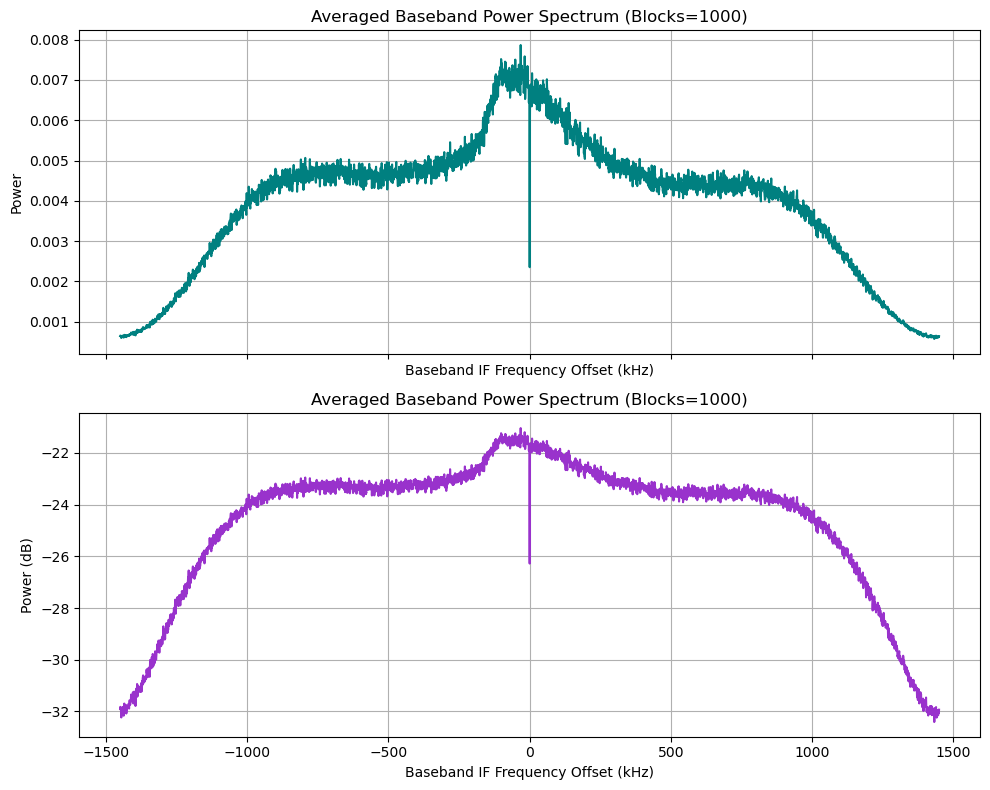

In [27]:
import numpy as np
import matplotlib.pyplot as plt

importdata = np.load("/home/radiopi/Lab_2_Work/Astro121/cassy_data3.npz")
indexdata  = importdata["arr_1"]          # shape ~ (captures, samples, 2)

sampling_rate = 2.9e6                     # <-- set correctly
fLO = 1420.395e6                          # <-- real center frequency

# Choose how many captures to average
M = min(1000, indexdata.shape[0])           # try 50 to start

# Use the same N for every FFT
N = indexdata.shape[1]

# Window (and a normalization so power scale is consistent)
window = np.hanning(N)
W2 = np.mean(window**2)                   # window power normalization

P_accum = np.zeros(N, dtype=np.float64)

for m in range(M):
    data = indexdata[m]                   # (N,2)
    x = data[:,0] + 1j*data[:,1]          # complex IQ

    # Remove DC offset (helps a lot)
    x = x - np.mean(x)

    # FFT
    X = np.fft.fftshift(np.fft.fft(x * window))
    P = (np.abs(X)**2) / (N**2 * W2)      # linear power, normalized

    P_accum += P

P_avg = P_accum / M

# Frequency axis (baseband)
f = np.fft.fftshift(np.fft.fftfreq(N, d=1/sampling_rate))  # Hz

# Convert to dB only at the end (add epsilon to avoid -inf)
P_avg_db = 10*np.log10(P_avg + 1e-20)



# Plotting 

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10,8), sharex=True)

# First Plot
ax1.plot(f/1e3, P_avg, color="teal")
ax1.set_xlabel("Baseband IF Frequency Offset (kHz)")
ax1.set_ylabel("Power")
ax1.set_title(f"Averaged Baseband Power Spectrum (Blocks={M})")
ax1.grid(True)

# Second Plot 
ax2.plot(f/1e3, P_avg_db, color="darkorchid")
ax2.set_xlabel("Baseband IF Frequency Offset (kHz)")
ax2.set_ylabel("Power (dB)")
#plt.xlim(-500,200)
ax2.set_title(f"Averaged Baseband Power Spectrum (Blocks={M})")
ax2.grid(True)

plt.tight_layout()
plt.show()

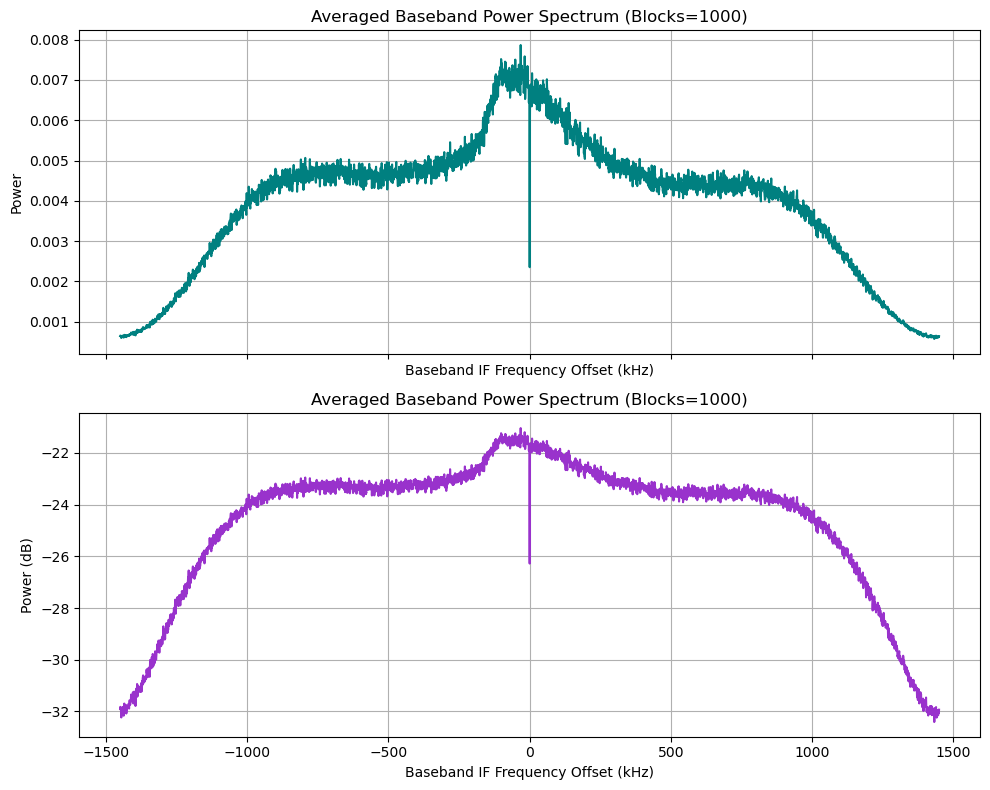

In [28]:
import numpy as np
import matplotlib.pyplot as plt

importdata = np.load("/home/radiopi/Lab_2_Work/Astro121/cassy_data3.npz")
indexdata  = importdata["arr_1"]          # shape ~ (captures, samples, 2)

sampling_rate = 2.9e6                     # <-- set correctly
fLO = 1420.395e6                          # <-- real center frequency

# Choose how many captures to average
M = min(1000, indexdata.shape[0])           # try 50 to start

# Use the same N for every FFT
N = indexdata.shape[1]

# Window (and a normalization so power scale is consistent)
window = np.hanning(N)
W2 = np.mean(window**2)                   # window power normalization

P_accum = np.zeros(N, dtype=np.float64)

for m in range(M):
    data = indexdata[m]                   # (N,2)
    x = data[:,0] + 1j*data[:,1]          # complex IQ

    # Remove DC offset (helps a lot)
    x = x - np.mean(x)

    # FFT
    X = np.fft.fftshift(np.fft.fft(x * window))
    P = (np.abs(X)**2) / (N**2 * W2)      # linear power, normalized

    P_accum += P

P_avg = P_accum / M

# Frequency axis (baseband)
f = np.fft.fftshift(np.fft.fftfreq(N, d=1/sampling_rate))  # Hz

# Convert to dB only at the end (add epsilon to avoid -inf)
P_avg_db = 10*np.log10(P_avg + 1e-20)



# Plotting 

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10,8), sharex=True)

# First Plot
ax1.plot(f/1e3, P_avg, color="teal")
ax1.set_xlabel("Baseband IF Frequency Offset (kHz)")
ax1.set_ylabel("Power")
ax1.set_title(f"Averaged Baseband Power Spectrum (Blocks={M})")
ax1.grid(True)

# Second Plot 
ax2.plot(f/1e3, P_avg_db, color="darkorchid")
ax2.set_xlabel("Baseband IF Frequency Offset (kHz)")
ax2.set_ylabel("Power (dB)")
#plt.xlim(-500,200)
ax2.set_title(f"Averaged Baseband Power Spectrum (Blocks={M})")
ax2.grid(True)

plt.tight_layout()
plt.show()

----- Input file shapes -----
cassy_data3.npz (1000, 4096, 2)
off1.npz (1000, 131072, 2)
bodytest1.npz (1000, 131072, 2)
nobodytest1.npz (1000, 131072, 2)

Using fixed NFFT = 4096 for ALL spectra.

GAIN G = 261.833 K
df_chan = 708.008 Hz, smooth window = 7 ch (~4.96 kHz)
sum_scold = 1.538898e+01, sum_diff = 1.763220e+01

UTC: 2026-02-18 19:31:00
Julian Date: 2461090.313194444

Horn pointing used for LSR correction:
Alt = 32.288699 deg, Az = 327.193742 deg
RA  = 227.317252774 deg
Dec = 62.832088246 deg

NOTE: ugradio returned a large value; assuming m/s and converting to km/s.

ugradio projected velocity correction = 3.434778 km/s


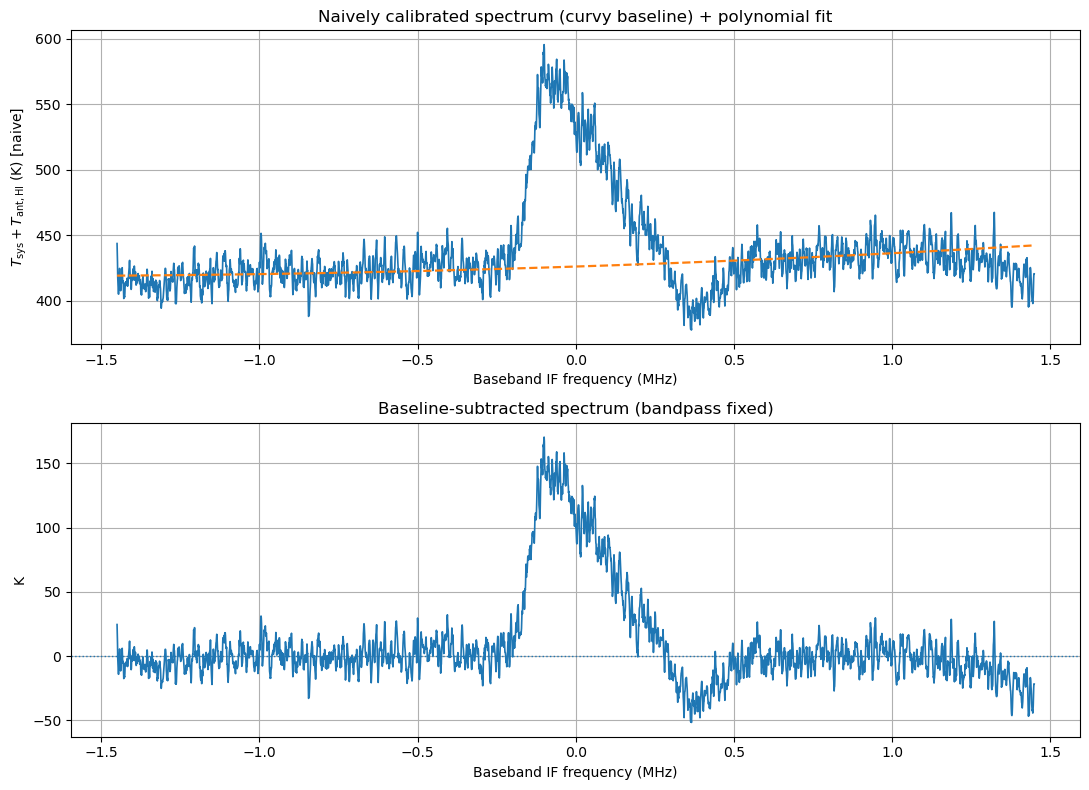

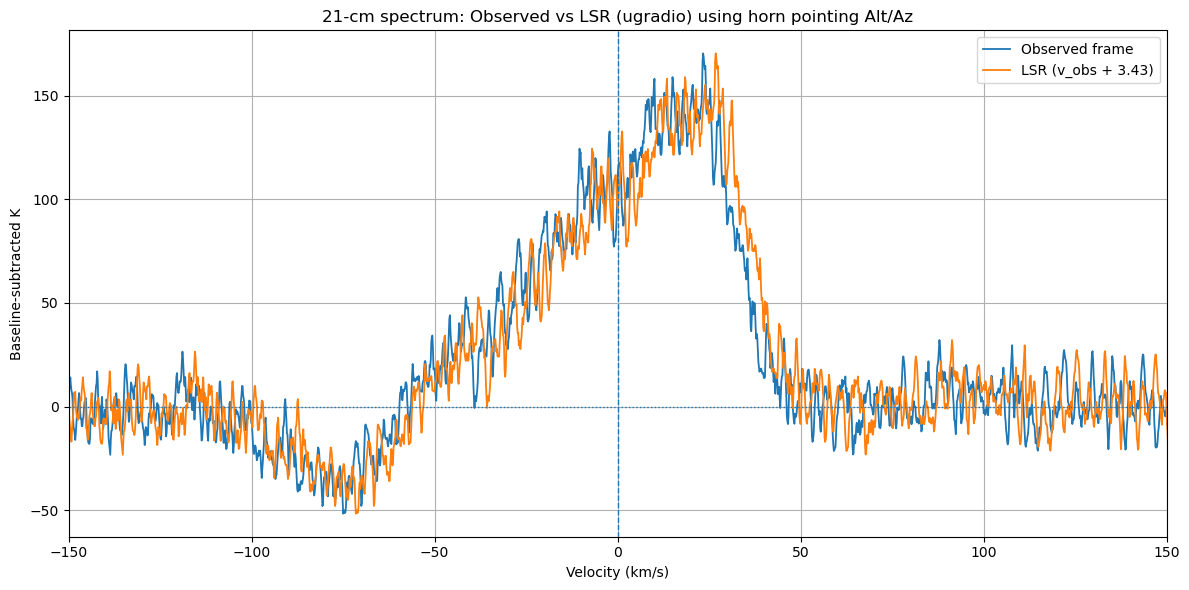


--- Peak (baseline-subtracted) ---
Peak T = 170.38 K
IF freq at peak = -0.099829 MHz
v_obs(peak) = 23.35 km/s
v_LSR_add(peak) = 26.78 km/s
v_LSR_sub(peak) = 19.91 km/s


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view

from astropy.time import Time
from astropy import units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz

import ugradio

# ============================================================
# 0) FILES (EDIT THESE 4 NAMES)
#    All must have arr_1 shaped (captures, samples, 2)
# ============================================================
BASE = "/home/radiopi/Lab_2_Work/Astro121/"

# ON/OFF for the l=120, b=0 pointing
ON_FILE   = BASE + "cassy_data3.npz"      # <-- your ON measurement
OFF_FILE  = BASE + "off1.npz"             # <-- your OFF measurement (EDIT!)

# CAL/COLD for gain (7.3)
CAL_FILE  = BASE + "bodytest1.npz"        # <-- hot/body (~300 K)
COLD_FILE = BASE + "nobodytest1.npz"      # <-- cold sky

# ============================================================
# 1) SDR / OBS SETTINGS
# ============================================================
fs  = 2.9e6           # Hz
fLO = 1420.395e6      # Hz
nu0 = 1420.4058e6     # Hz (rest HI)
c_kms = 299792.458    # km/s

M_onoff = 1000
M_cal   = 1000

combine_method = "mean"     # try "median" if RFI
smooth_method  = "mean"

T_sys_cal = 300.0           # K (given)

# Force a common FFT length across ALL files to prevent shape mismatch
NFFT = 4096                 # <-- FIX for broadcasting error (choose 4096 or smaller common length)

# Observation time (for LSR correction)
utc_time = "2026-02-18 19:31:00"
t_obs = Time(utc_time, scale="utc")

# Observatory location (Campbell Hall / Berkeley)
location = EarthLocation(lat=37.873199*u.deg, lon=-122.2573*u.deg, height=0*u.m)

# Target Galactic coordinates (metadata only)
l_deg = 120.0
b_deg = 0.0

# ============================================================
# 2) HELPER FUNCTIONS
# ============================================================
def moving_smooth(y, w, method="mean"):
    w = int(w)
    if w < 2:
        return y.copy()
    if w % 2 == 0:
        w += 1
    pad = w // 2
    ypad = np.pad(y, (pad, pad), mode="reflect")

    if method == "mean":
        kernel = np.ones(w, dtype=float) / w
        return np.convolve(ypad, kernel, mode="valid")
    elif method == "median":
        windows = sliding_window_view(ypad, window_shape=w)
        return np.median(windows, axis=-1)
    else:
        raise ValueError("method must be 'mean' or 'median'")

def combined_power_spectrum(npz_file, fs, M=None, combine="mean", NFFT=4096):
    """
    Load arr_1 from npz and compute combined (mean/median) power spectrum.
    Uses a fixed FFT length NFFT so all files produce same-length spectra.
    """
    arr = np.load(npz_file)["arr_1"]  # (captures, N, 2)
    ncap, N, _ = arr.shape
    if M is None:
        M = ncap
    M = min(M, ncap)

    # Use a consistent FFT length across files
    Nuse = min(int(NFFT), N)
    if Nuse < 16:
        raise ValueError(f"NFFT too small after min(): Nuse={Nuse}")

    window = np.hanning(Nuse)
    W2 = np.mean(window**2)

    P_stack = np.empty((M, Nuse), dtype=np.float64)
    for m in range(M):
        x = arr[m, :Nuse, 0] + 1j * arr[m, :Nuse, 1]
        x = x - np.mean(x)
        X = np.fft.fftshift(np.fft.fft(x * window))
        P_stack[m] = (np.abs(X)**2) / (Nuse**2 * W2)

    if combine == "mean":
        P_comb = np.mean(P_stack, axis=0)
    elif combine == "median":
        P_comb = np.median(P_stack, axis=0)
    else:
        raise ValueError("combine must be 'mean' or 'median'")

    f_if = np.fft.fftshift(np.fft.fftfreq(Nuse, d=1/fs))  # Hz
    return f_if, P_comb

# ============================================================
# 3) PRINT SHAPES (DEBUG)
# ============================================================
print("----- Input file shapes -----")
for fn in [ON_FILE, OFF_FILE, CAL_FILE, COLD_FILE]:
    arr = np.load(fn)["arr_1"]
    print(fn.split("/")[-1], arr.shape)
print(f"\nUsing fixed NFFT = {NFFT} for ALL spectra.\n")

# ============================================================
# 4) COMPUTE GAIN G (7.3)
# ============================================================
f_cal,  s_cal  = combined_power_spectrum(CAL_FILE,  fs, M=M_cal, combine=combine_method, NFFT=NFFT)
f_cold, s_cold = combined_power_spectrum(COLD_FILE, fs, M=M_cal, combine=combine_method, NFFT=NFFT)

if not np.allclose(f_cal, f_cold):
    raise RuntimeError("CAL and COLD frequency axes do not match (fs/NFFT mismatch).")

# smooth over ~1 km/s (~4.74 kHz)
df_chan = np.abs(f_cal[1] - f_cal[0])
df_target_hz = nu0 * (1e3 / 299792458.0)
w_chan = max(1, int(np.round(df_target_hz / df_chan)))

s_cal_s  = moving_smooth(s_cal,  w=w_chan, method=smooth_method)
s_cold_s = moving_smooth(s_cold, w=w_chan, method=smooth_method)

sum_scold = np.sum(s_cold_s)
sum_diff  = np.sum(s_cal_s - s_cold_s)
if sum_diff <= 0:
    raise RuntimeError("sum(s_cal - s_cold) <= 0: calibration not hotter than cold sky?")

G = T_sys_cal * (sum_scold / sum_diff)

print(f"GAIN G = {G:.3f} K")
print(f"df_chan = {df_chan:.3f} Hz, smooth window = {w_chan} ch (~{w_chan*df_chan/1e3:.2f} kHz)")
print(f"sum_scold = {sum_scold:.6e}, sum_diff = {sum_diff:.6e}\n")

# ============================================================
# 5) COMPUTE NAIVE CALIBRATED SPECTRUM:  T_naive = r * G
# ============================================================
f_on,  s_on  = combined_power_spectrum(ON_FILE,  fs, M=M_onoff, combine=combine_method, NFFT=NFFT)
f_off, s_off = combined_power_spectrum(OFF_FILE, fs, M=M_onoff, combine=combine_method, NFFT=NFFT)

if not np.allclose(f_on, f_off):
    raise RuntimeError("ON and OFF frequency axes do not match (fs/NFFT mismatch).")

s_on_s  = moving_smooth(s_on,  w=w_chan, method=smooth_method)
s_off_s = moving_smooth(s_off, w=w_chan, method=smooth_method)

r_line  = s_on_s / (s_off_s + 1e-30)
T_naive = r_line * G

# IF axis (MHz)
f_if = f_on
f_if_mhz = f_if / 1e6

# ============================================================
# 6) BASELINE REMOVAL USING OFF-LINE CHANNELS
#    Off-line regions: -1.2→-0.6 MHz and +0.6→+1.2 MHz
# ============================================================
offline = ((f_if_mhz > -1.2) & (f_if_mhz < -0.6)) | ((f_if_mhz > 0.6) & (f_if_mhz < 1.2))

if np.sum(offline) < 20:
    raise RuntimeError("Too few off-line channels in the specified ranges. Check NFFT/fs or ranges.")

# Fit 2nd-order polynomial baseline
p = np.polyfit(f_if_mhz[offline], T_naive[offline], deg=2)
baseline_poly = np.polyval(p, f_if_mhz)

T_fixed = T_naive - baseline_poly

# Define HI excess temperature for plotting (baseline-subtracted)
T_HI = T_fixed

# ============================================================
# 7) CONVERT TO RF FREQUENCY AND OBSERVED VELOCITY
# ============================================================
nu_rf = fLO + f_if  # Hz

delta_nu = nu_rf - nu0
v_obs_kms = -c_kms * (delta_nu / nu0)  # km/s

# ============================================================
# 8) 7.5 LSR CORRECTION USING YOUR *HORN POINTING* (ALT/AZ)
#     (alt/az came from HA(120,0) -> vec_to_altaz output)
# ============================================================
print("UTC:", utc_time)
print("Julian Date:", f"{t_obs.jd:.9f}")

# --- Your horn pointing numbers (DO NOT change) ---
alt_deg = 32.28869868049251
az_deg  = 327.19374182616133

# Build AltAz coordinate for the horn pointing
pointing_altaz = SkyCoord(
    alt=alt_deg * u.deg,
    az=az_deg * u.deg,
    frame=AltAz(obstime=t_obs, location=location)
)

# Convert to ICRS RA/Dec
pointing_icrs = pointing_altaz.icrs
ra_deg  = pointing_icrs.ra.deg
dec_deg = pointing_icrs.dec.deg

print("\nHorn pointing used for LSR correction:")
print(f"Alt = {alt_deg:.6f} deg, Az = {az_deg:.6f} deg")
print(f"RA  = {ra_deg:.9f} deg")
print(f"Dec = {dec_deg:.9f} deg")

# ugradio LSR correction (argument order you provided)
jd = t_obs.jd

try:
    v_proj = ugradio.doppler.get_projected_velocity(ra_deg, dec_deg, jd)
except TypeError:
    v_proj = ugradio.doppler.get_projected_velocity(
        ra_deg, dec_deg, jd,
        obs_lat=37.873199, obs_lon=-122.2573
    )

# If ugradio returns m/s, convert to km/s
if np.abs(v_proj) > 500:
    print("\nNOTE: ugradio returned a large value; assuming m/s and converting to km/s.")
    v_proj = v_proj / 1000.0

print(f"\nugradio projected velocity correction = {v_proj:.6f} km/s")

# Apply both sign conventions (you can choose which is right)
v_lsr_add = v_obs_kms + v_proj
v_lsr_sub = v_obs_kms - v_proj

# ============================================================
# 9) PLOTS (FIG 1 STYLE + OBS vs LSR)
# ============================================================

# Figure 1 style: naive + baseline and baseline-subtracted
plt.figure(figsize=(11, 8))

ax1 = plt.subplot(2,1,1)
ax1.plot(f_if_mhz, T_naive, linewidth=1.2)
ax1.plot(f_if_mhz, baseline_poly, linestyle="--", linewidth=1.6)
ax1.set_title("Naively calibrated spectrum (curvy baseline) + polynomial fit")
ax1.set_ylabel(r"$T_{\rm sys}+T_{\rm ant,HI}$ (K) [naive]")
ax1.set_xlabel("Baseband IF frequency (MHz)")
ax1.grid(True)

ax2 = plt.subplot(2,1,2, sharex=ax1)
ax2.plot(f_if_mhz, T_HI, linewidth=1.2)
ax2.axhline(0, linestyle=":", linewidth=1.0)
ax2.set_title("Baseline-subtracted spectrum (bandpass fixed)")
ax2.set_ylabel("K")
ax2.set_xlabel("Baseband IF frequency (MHz)")
ax2.grid(True)

plt.tight_layout()
plt.show()

# Velocity comparison plot (show + sign by default)
plt.figure(figsize=(12, 6))
plt.plot(v_obs_kms, T_HI, label="Observed frame", linewidth=1.3)
plt.plot(v_lsr_add, T_HI, label=f"LSR (v_obs + {v_proj:.2f})", linewidth=1.3)
# Uncomment to compare the opposite sign:
# plt.plot(v_lsr_sub, T_HI, label=f"LSR (v_obs - {v_proj:.2f})", linewidth=1.1, alpha=0.7)

plt.axhline(0, linestyle=":", linewidth=1.0)
plt.axvline(0, linestyle="--", linewidth=1.0)
plt.xlim(-150, 150)
plt.xlabel("Velocity (km/s)")
plt.ylabel("Baseline-subtracted K")
plt.title("21-cm spectrum: Observed vs LSR (ugradio) using horn pointing Alt/Az")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Peak printout
imax = np.argmax(T_HI)
print("\n--- Peak (baseline-subtracted) ---")
print(f"Peak T = {T_HI[imax]:.2f} K")
print(f"IF freq at peak = {f_if_mhz[imax]:.6f} MHz")
print(f"v_obs(peak) = {v_obs_kms[imax]:.2f} km/s")
print(f"v_LSR_add(peak) = {v_lsr_add[imax]:.2f} km/s")
print(f"v_LSR_sub(peak) = {v_lsr_sub[imax]:.2f} km/s")


---- FAILS ----

---- Summary (tone power in SDR units) ----
file                            amp(dBm)  toneIF(kHz)         P_meas     M     type
SDR_cable_pwr_loss1.npz            -20.0      -405.00   1.288093e-01   200     REAL
SDR_cable_pwr_loss2.npz            -20.0      -405.00   1.036161e-01   200     REAL
SDR_cable_pwr_loss3.npz            -20.0      -405.00   1.375702e-01   200     REAL
SDR_cable_pwr_loss4.npz            -20.0      -405.00   1.704485e-01   200     REAL
SDR_cable_pwr_loss5.npz            -20.0      -405.00   1.344261e-01   200     REAL
SDR_power_calibration.npz          -20.0     -1000.10   5.558364e+03   200     REAL
SDR_power_calibration2.npz         -20.0     -1000.10   5.548647e+03   200     REAL
SDR_power_calibration3.npz         -20.0     -1000.10   5.564773e+03   200     REAL
SDR_power_test.npz                  10.0       569.95   1.726375e+01   200       IQ
SDR_power_test2.npz                 10.0     -1000.07   5.763821e+03   200     REAL
SDR_shcable_pw

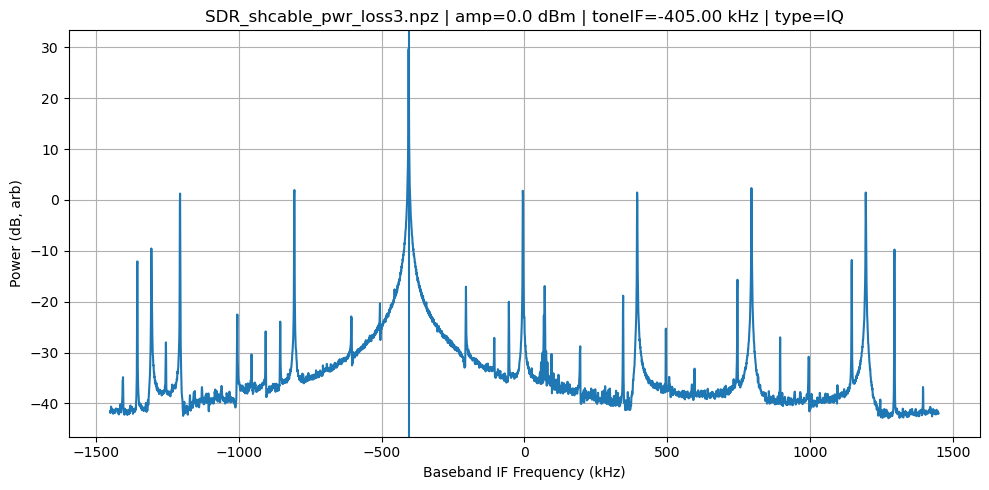

In [18]:
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt

# ============================
# CONFIG
# ============================
BASE = "/home/radiopi/Lab_2_Work/Astro121/"
PATTERN = "SDR_*.npz"

F_CENTER_HZ = 1420.405e6  # Hz
NFFT = 4096
M_CAP = 200          # None = all captures
TONE_BW_HZ = 5000.0  # integrate ±5 kHz around tone

# ============================
# METADATA
# ============================
def parse_arr0(arr0):
    meta = {}
    for item in arr0:
        s = item.decode() if isinstance(item, (bytes, np.bytes_)) else str(item)
        s = s.strip()
        if ":" not in s:
            meta.setdefault("misc", []).append(s)
            continue
        k, v = s.split(":", 1)
        meta[k.strip()] = v.strip()
    return meta

def parse_number_with_units(s):
    if s is None:
        return None
    m = re.search(r"[-+]?\d+(\.\d+)?([eE][-+]?\d+)?", str(s))
    return float(m.group(0)) if m else None

def dbm_to_watts(p_dbm):
    return 10 ** ((p_dbm - 30.0) / 10.0)

# ============================
# DATA SHAPE NORMALIZER
# ============================
def normalize_captures(arr1):
    """
    Returns:
      x_real: (ncap, nsamp) real array
      x_cplx: (ncap, nsamp) complex array or None

    Supports:
      (ncap, nsamp, 2) IQ
      (nsamp, 2) IQ
      (ncap, nsamp) real
      (nsamp,) real
    """
    arr1 = np.asarray(arr1)

    # Case: (ncap, nsamp, 2) complex IQ
    if arr1.ndim == 3 and arr1.shape[2] == 2:
        x = arr1[..., 0] + 1j * arr1[..., 1]   # (ncap, nsamp)
        return None, x

    # Case: (nsamp, 2) single capture IQ
    if arr1.ndim == 2 and arr1.shape[1] == 2:
        x = arr1[:, 0] + 1j * arr1[:, 1]       # (nsamp,)
        x = x[None, :]                         # (1, nsamp)
        return None, x

    # Case: (ncap, nsamp) real captures (YOUR FILES)
    if arr1.ndim == 2 and arr1.shape[1] != 2:
        return arr1.astype(float), None

    # Case: (nsamp,) real single capture
    if arr1.ndim == 1:
        return arr1[None, :].astype(float), None

    raise ValueError(f"Unsupported arr_1 shape: {arr1.shape}")

# ============================
# SPECTRUM + TONE POWER
# ============================
def measure_tone_power_from_npz(npz_path, f_center_hz=F_CENTER_HZ, nfft=NFFT, m_cap=M_CAP, tone_bw_hz=TONE_BW_HZ):
    data = np.load(npz_path)
    meta = parse_arr0(data["arr_0"])
    arr1 = data["arr_1"]

    # ---- parse metadata ----
    f_mhz = parse_number_with_units(meta.get("Frequency"))
    f_tone_hz = (f_mhz * 1e6) if f_mhz is not None else None

    p_dbm = parse_number_with_units(meta.get("Amplitude"))
    p_watts = dbm_to_watts(p_dbm) if p_dbm is not None else None

    fs = (
        parse_number_with_units(meta.get("Sampling Rate"))
        or parse_number_with_units(meta.get("SamplingRate"))
        or 2.9e6
    )

    # ---- normalize data shape ----
    x_real, x_cplx = normalize_captures(arr1)

    if x_cplx is not None:
        ncap, nsamp = x_cplx.shape
        is_complex = True
    else:
        ncap, nsamp = x_real.shape
        is_complex = False

    M = ncap if (m_cap is None) else min(int(m_cap), ncap)

    Nuse = min(int(nfft), nsamp)
    if Nuse < 64:
        raise ValueError(f"{os.path.basename(npz_path)}: Nuse too small ({Nuse})")

    window = np.hanning(Nuse)
    W2 = np.mean(window**2)
    f_if = np.fft.fftshift(np.fft.fftfreq(Nuse, d=1/fs))

    # expected IF tone position
    if f_tone_hz is not None:
        f0_if = f_tone_hz - f_center_hz
        tone_mask = (f_if >= (f0_if - tone_bw_hz)) & (f_if <= (f0_if + tone_bw_hz))
    else:
        f0_if = None
        tone_mask = None

    P_accum = np.zeros(Nuse, dtype=np.float64)

    for m in range(M):
        if is_complex:
            x = x_cplx[m, :Nuse]
        else:
            x = x_real[m, :Nuse]

        x = x - np.mean(x)

        X = np.fft.fftshift(np.fft.fft(x * window))
        P = (np.abs(X)**2) / (Nuse**2 * W2)
        P_accum += P

    P_avg = P_accum / M

    # tone power
    if tone_mask is not None and np.any(tone_mask):
        tone_power_meas = np.sum(P_avg[tone_mask])
        tone_f_meas = f0_if
        method = "expected-window"
    else:
        dc_exclude = np.abs(f_if) < 5e3
        P_tmp = P_avg.copy()
        P_tmp[dc_exclude] = 0.0
        kpeak = int(np.argmax(P_tmp))
        fpeak = f_if[kpeak]
        tone_mask2 = (f_if >= (fpeak - tone_bw_hz)) & (f_if <= (fpeak + tone_bw_hz))
        tone_power_meas = np.sum(P_avg[tone_mask2])
        tone_f_meas = fpeak
        method = "peak-window"

    return {
        "file": os.path.basename(npz_path),
        "fs": fs,
        "Nuse": Nuse,
        "M_used": M,
        "amp_dbm": p_dbm,
        "amp_watts": p_watts,
        "f_tone_hz": f_tone_hz,
        "f_if_measured_hz": tone_f_meas,
        "tone_power_meas": tone_power_meas,
        "method": method,
        "is_complex": is_complex,
        "meta": meta,
        "f_if_axis": f_if,
        "P_avg": P_avg,
    }

# ============================
# RUN
# ============================
files = sorted(glob.glob(os.path.join(BASE, PATTERN)))
if not files:
    raise FileNotFoundError(f"No files matched {BASE}{PATTERN}")

results, fails = [], []
for fp in files:
    try:
        results.append(measure_tone_power_from_npz(fp))
    except Exception as e:
        fails.append((os.path.basename(fp), str(e)))

print("\n---- FAILS ----")
for name, msg in fails:
    print("FAILED:", name, "->", msg)

print("\n---- Summary (tone power in SDR units) ----")
print("file".ljust(30), "amp(dBm)".rjust(9), "toneIF(kHz)".rjust(12), "P_meas".rjust(14), "M".rjust(5), "type".rjust(8))
for r in results:
    dtype = "IQ" if r["is_complex"] else "REAL"
    print(
        r["file"].ljust(30),
        f"{r['amp_dbm'] if r['amp_dbm'] is not None else 'NA':>9}",
        f"{r['f_if_measured_hz']/1e3:>12.2f}",
        f"{r['tone_power_meas']:>14.6e}",
        f"{r['M_used']:>5}",
        f"{dtype:>8}",
    )

# plot first result
if results:
    ex = [r for r in results if r["file"] == "SDR_shcable_pwr_loss3.npz"][0]
    plt.figure(figsize=(10,5))
    plt.plot(ex["f_if_axis"]/1e3, 10*np.log10(ex["P_avg"] + 1e-30))
    plt.axvline(x=-405)
    plt.xlabel("Baseband IF Frequency (kHz)")
    plt.ylabel("Power (dB, arb)")
    plt.title(f"{ex['file']} | amp={ex['amp_dbm']} dBm | toneIF={ex['f_if_measured_hz']/1e3:.2f} kHz | type={'IQ' if ex['is_complex'] else 'REAL'}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

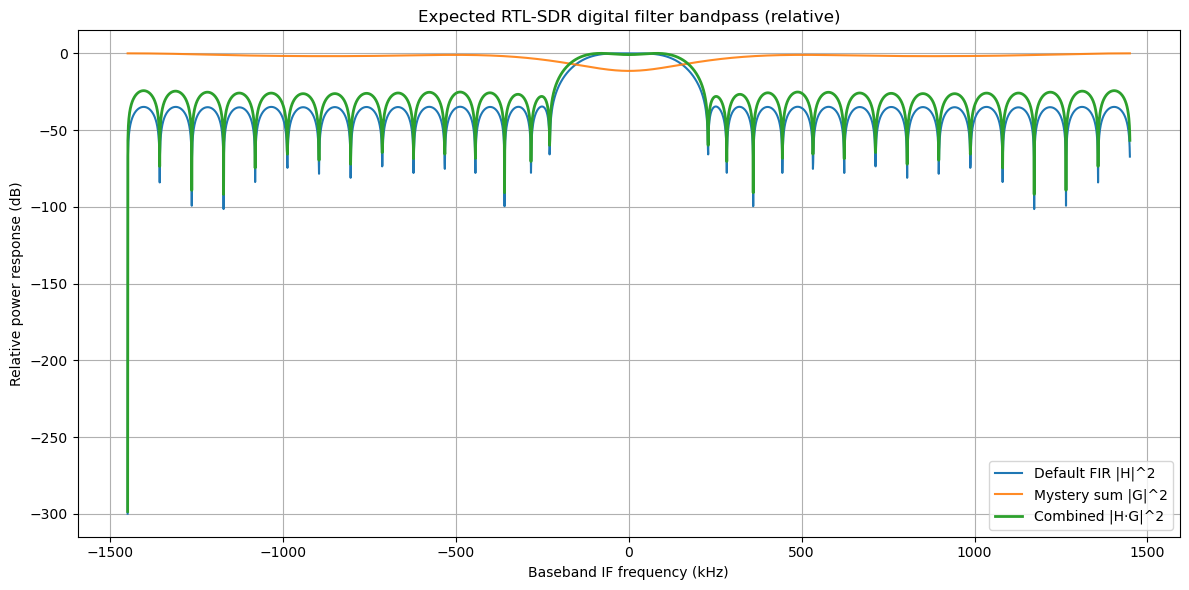

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Your spectrum settings
# -----------------------------
fs = 2.9e6     # Hz (your SDR sample rate after decimation)
NFFT = 4096    # match what you're using for spectra

# Frequency axis used by your FFT spectra
f_if = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1/fs))  # Hz

# -----------------------------
# 1) Default RTL FIR coefficients (32 taps)
# -----------------------------
h = np.array([
    -54, -36, -41, -40, -32, -14,  14,  53,
    101, 156, 215, 273, 327, 372, 404, 421,
    421, 404, 372, 327, 273, 215, 156, 101,
     53,  14, -14, -32, -40, -41, -36, -54
], dtype=float)

# Normalize (scale doesn't matter for shape, but helps plotting)
h = h / np.sum(h)

# -----------------------------
# 2) "Mystery summing filter" coefficients (11 taps)
# -----------------------------
g = np.array([
    -1/8, -1/4, -3/4, -1/2, -1, 8, -1, -1/2, -3/4, -1/4, -1/8
], dtype=float)
g = g / np.sum(g)

# -----------------------------
# 3) Compute DFT frequency response on your FFT frequencies
# -----------------------------
def freq_response(coeffs, f_hz, fs_hz):
    n = np.arange(len(coeffs))
    # H(f) = sum h[n] * exp(-i 2π f n / fs)
    E = np.exp(-1j * 2*np.pi * (f_hz[:, None] * n[None, :] / fs_hz))
    H = E @ coeffs
    return H

H_fir = freq_response(h, f_if, fs)
H_sum = freq_response(g, f_if, fs)

# Combined response if both filters apply (cascade)
H_total = H_fir * H_sum

# -----------------------------
# 4) Convert to power response (what matters for your spectra)
# -----------------------------
P_fir   = np.abs(H_fir)**2
P_sum   = np.abs(H_sum)**2
P_total = np.abs(H_total)**2

# Normalize to 0 dB at max for easy comparison
def norm_db(P):
    Pn = P / np.max(P)
    return 10*np.log10(Pn + 1e-30)

P_fir_db   = norm_db(P_fir)
P_sum_db   = norm_db(P_sum)
P_total_db = norm_db(P_total)

# -----------------------------
# 5) Plot
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(f_if/1e3, P_fir_db,   label="Default FIR |H|^2")
plt.plot(f_if/1e3, P_sum_db,   label="Mystery sum |G|^2", alpha=0.9)
plt.plot(f_if/1e3, P_total_db, label="Combined |H·G|^2", linewidth=2.0)
plt.xlabel("Baseband IF frequency (kHz)")
plt.ylabel("Relative power response (dB)")
plt.title("Expected RTL-SDR digital filter bandpass (relative)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# SQAURE TIME SQUARE TIME SQUARE TIME 

In [44]:
import numpy as np
import matplotlib.pyplot as plt

importdata = np.load("/home/radiopi/Lab_2_Work/Astro121/SDR_power_test2.npz")
indexdata  = importdata["arr_1"]          # shape ~ (captures, samples, 2)

# Need to plot this as just normal power spectra. Rip code off of first lab. Looked fine on the terminal.

In [45]:
# Measured wire to be 26 feet and 7 inches

In [2]:
# SDR is not a perfect terminator -- need to add a 50 ohm terminator

# Measured speed of light in a 26 foot cable to be 56% that of the speed of light in a vacuum 

In [13]:
# Moving on to calibrating the FIR coefficients 

ugradio.dft.dft([-54, -36, -41, -32, -14, 14, 53, 101, 156, 215, 273, 327, 372, 404, 421], vsamp=2.9e6)

# first output is the same frequencies we input
# second output is the discrete fourier output of the array we put in, in this case the FIR filter coefficients

(array([-1450000.        , -1256666.66666667, -1063333.33333333,
         -870000.        ,  -676666.66666667,  -483333.33333333,
         -290000.        ,   -96666.66666667,    96666.66666667,
          290000.        ,   483333.33333333,   676666.66666667,
          870000.        ,  1063333.33333333,  1256666.66666667]),
 array([ 7.19790069e-13 +379.j        , -6.53739982e+01 +111.37826305j,
        -2.61333107e+02 +309.58986395j, -1.65342820e+02   -7.49474845j,
        -5.24529020e+02  +64.90849957j, -1.54152522e+02 -268.j        ,
        -8.92758647e+02 -896.99474845j,  1.25883281e+03-1338.87989952j,
         1.25883281e+03+1338.87989952j, -8.92758647e+02 +896.99474845j,
        -1.54152522e+02 +268.j        , -5.24529020e+02  -64.90849957j,
        -1.65342820e+02   +7.49474845j, -2.61333107e+02 -309.58986395j,
        -6.53739982e+01 -111.37826305j]))

In [14]:
# I am not entirely certain we need to change the FIR coefficients for the lab report. 
# I think it builds credibility in our arguement when writing the report, but ultimately is not crucial. 
# I am going to move on now to s9.3 for the sake of wrapping up work on the horn. Calibrating the SDR can be done without the horn and simply an oscilloscope and a wave genertator.

In [15]:
# Took a picture of the amplifiers in the box up at the horn. 
# Still need to look up the gain (in dB) on respective datasheets for each amplifier

In [1]:
# cassytestforcleardata (a test of what we can see when pointing at the constellation casseopia (l,b) ~= (120,0))


import numpy as np
import matplotlib.pyplot as plt

importdata = np.load("cassytestforcleardata.npz")
indexdata  = importdata["arr_1"]          # shape ~ (captures, samples, 2)

sampling_rate = 2.9e6                     # <-- set correctly
fLO = 1420.395e6                          # <-- real center frequency

# Choose how many captures to average
M = min(1000, indexdata.shape[0])           # try 50 to start

# Use the same N for every FFT
N = indexdata.shape[1]

# Window (and a normalization so power scale is consistent)
window = np.hanning(N)
W2 = np.mean(window**2)                   # window power normalization

P_accum = np.zeros(N, dtype=np.float64)

for m in range(M):
    data = indexdata[m]                   # (N,2)
    x = data[:,0] + 1j*data[:,1]          # complex IQ

    # Remove DC offset (helps a lot)
    x = x - np.mean(x)

    # FFT
    X = np.fft.fftshift(np.fft.fft(x * window))
    P = (np.abs(X)**2) / (N**2 * W2)      # linear power, normalized

    P_accum += P

P_avg = P_accum / M

# Frequency axis (baseband)
f = np.fft.fftshift(np.fft.fftfreq(N, d=1/sampling_rate))  # Hz

# Convert to dB only at the end (add epsilon to avoid -inf)
P_avg_db = 10*np.log10(P_avg + 1e-20)



# Plotting 

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10,8), sharex=True)

# First Plot
ax1.plot(f/1e3, P_avg, color="teal")
ax1.set_xlabel("Baseband IF Frequency Offset (kHz)")
ax1.set_ylabel("Power")
ax1.set_title(f"Averaged Baseband Power Spectrum (Blocks={M})")
ax1.grid(True)

# Second Plot 
ax2.plot(f/1e3, P_avg_db, color="darkorchid")
ax2.set_xlabel("Baseband IF Frequency Offset (kHz)")
ax2.set_ylabel("Power (dB)")
#plt.xlim(-500,200)
ax2.set_title(f"Averaged Baseband Power Spectrum (Blocks={M})")
ax2.grid(True)

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'cassytestforcleardata.npz'